In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/dataset.csv")

print(df.shape)
print(df.dtypes)
df.head()

(114000, 21)
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [9]:
# Valori nulli per colonna
print(df.isnull().sum())
print()

# Righe duplicate
print(f"Duplicate rows: {df.duplicated().sum()}")

# Rimuovi duplicati e righe con valori nulli
df = df.drop_duplicates()
df = df.dropna()

# Rimuovi la colonna "Unnamed: 0" che è solo un indice inutile
df = df.drop(columns=["Unnamed: 0"])

print(f"\nDataset after cleaning: {df.shape}")

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicate rows: 0

Dataset after cleaning: (113999, 20)


## Cella 3 — Le 10 canzoni più popolari:

In [10]:
top_songs = df[["track_name", "artists", "popularity"]]\
    .sort_values("popularity", ascending=False)\
    .drop_duplicates("track_name")\
    .head(10)

print(top_songs.to_string(index=False))

                           track_name                    artists  popularity
            Unholy (feat. Kim Petras)       Sam Smith;Kim Petras         100
Quevedo: Bzrp Music Sessions, Vol. 52           Bizarrap;Quevedo          99
                           La Bachata              Manuel Turizo          98
                      I'm Good (Blue)    David Guetta;Bebe Rexha          98
                     Tití Me Preguntó                  Bad Bunny          97
                      Me Porto Bonito Bad Bunny;Chencho Corleone          97
                               Efecto                  Bad Bunny          96
                  Under The Influence                Chris Brown          96
                      I Ain't Worried                OneRepublic          96
                        Ojitos Lindos    Bad Bunny;Bomba Estéreo          95


## Cella 4 — I 10 artisti con più tracce:

/tmp/ipykernel_2919/3785807951.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")


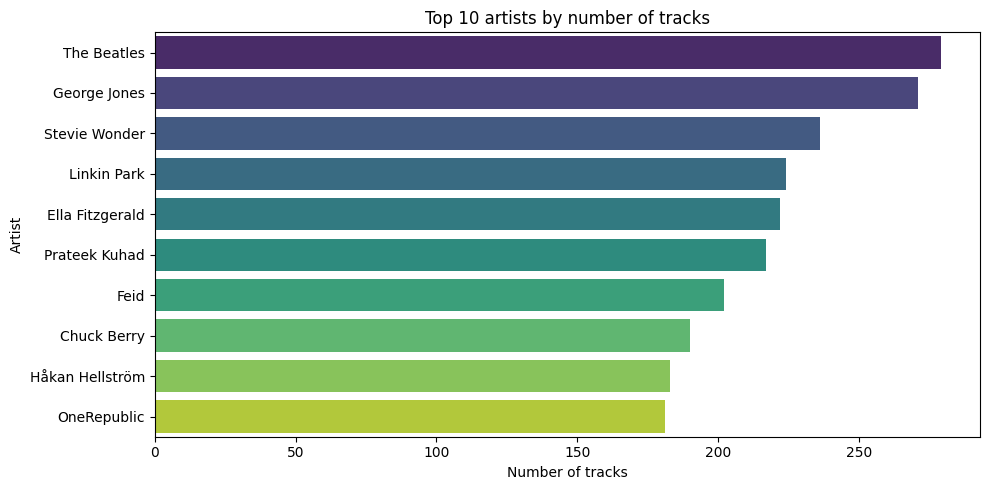

In [11]:
top_artists = df["artists"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")
plt.title("Top 10 artists by number of tracks")
plt.xlabel("Number of tracks")
plt.ylabel("Artist")
plt.tight_layout()
plt.savefig("../output/charts/top_artists.png", dpi=150, bbox_inches="tight")
plt.show()

## Cella 5 — Distribuzione della popolarità:

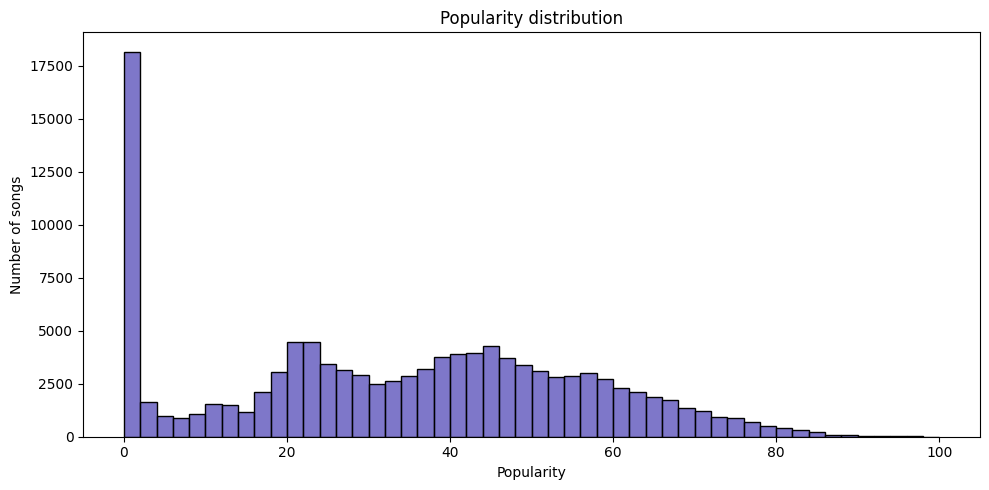

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["popularity"], bins=50, color="#534AB7")
plt.title("Popularity distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of songs")
plt.tight_layout()
plt.savefig("../output/charts/popularity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Cella 6 — Popolarità media per genere (top 15):

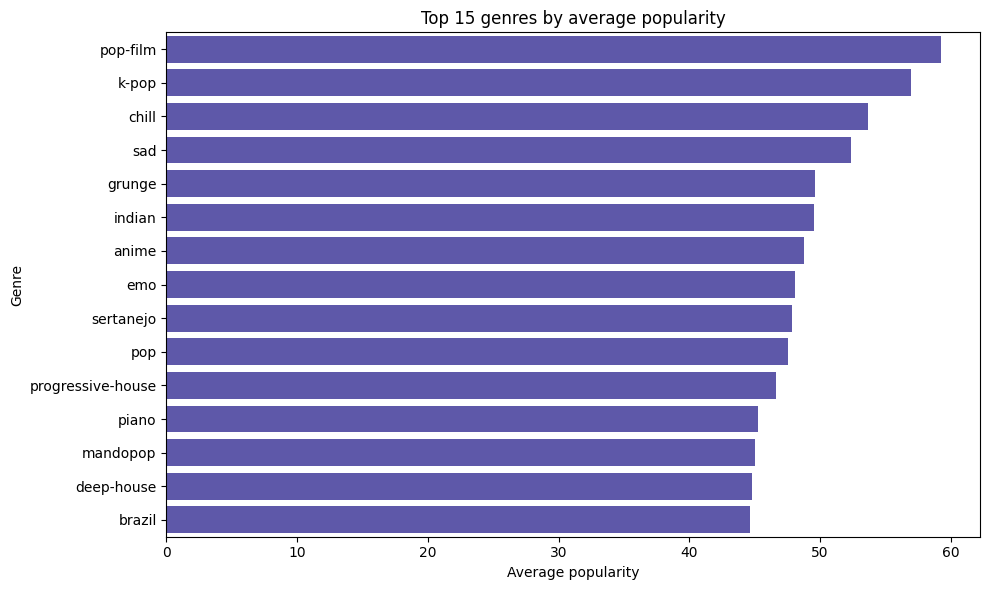

In [13]:
top_genres = df.groupby("track_genre")["popularity"]\
    .mean()\
    .sort_values(ascending=False)\
    .head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, color="#534AB7")
plt.title("Top 15 genres by average popularity")
plt.xlabel("Average popularity")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("../output/charts/top_genres.png", dpi=150, bbox_inches="tight")
plt.show()

## Cella 7 — Correlazione tra energy e danceability:

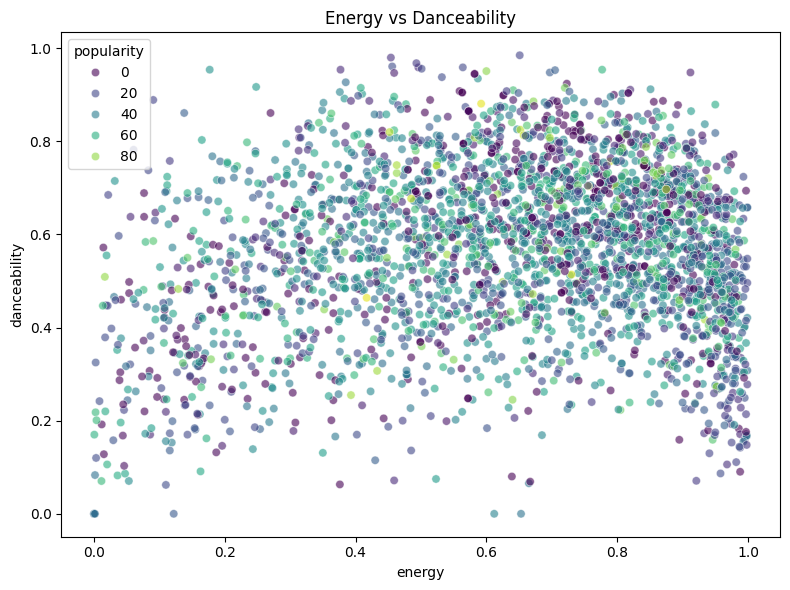

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(3000), x="energy", y="danceability",
                hue="popularity", palette="viridis", alpha=0.6)
plt.title("Energy vs Danceability")
plt.tight_layout()
plt.savefig("../output/charts/energy_danceability.png", dpi=150, bbox_inches="tight")
plt.show()

## Cella 8 — Durata media per genere (top 10):

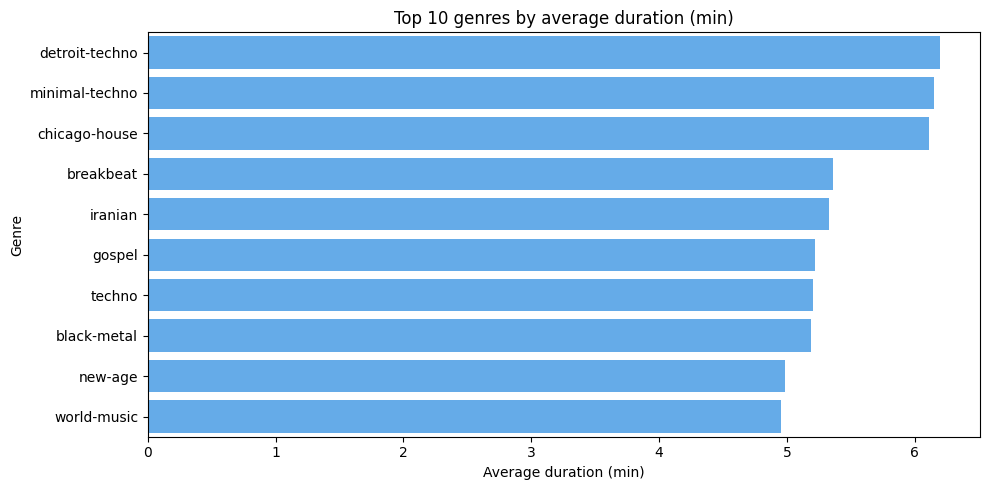

In [15]:
df["duration_min"] = df["duration_ms"] / 60000

top_duration = df.groupby("track_genre")["duration_min"]\
    .mean()\
    .sort_values(ascending=False)\
    .head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_duration.values, y=top_duration.index, color="#4facfe")
plt.title("Top 10 genres by average duration (min)")
plt.xlabel("Average duration (min)")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("../output/charts/duration_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()

## Cella 9 — Heatmap correlazioni:

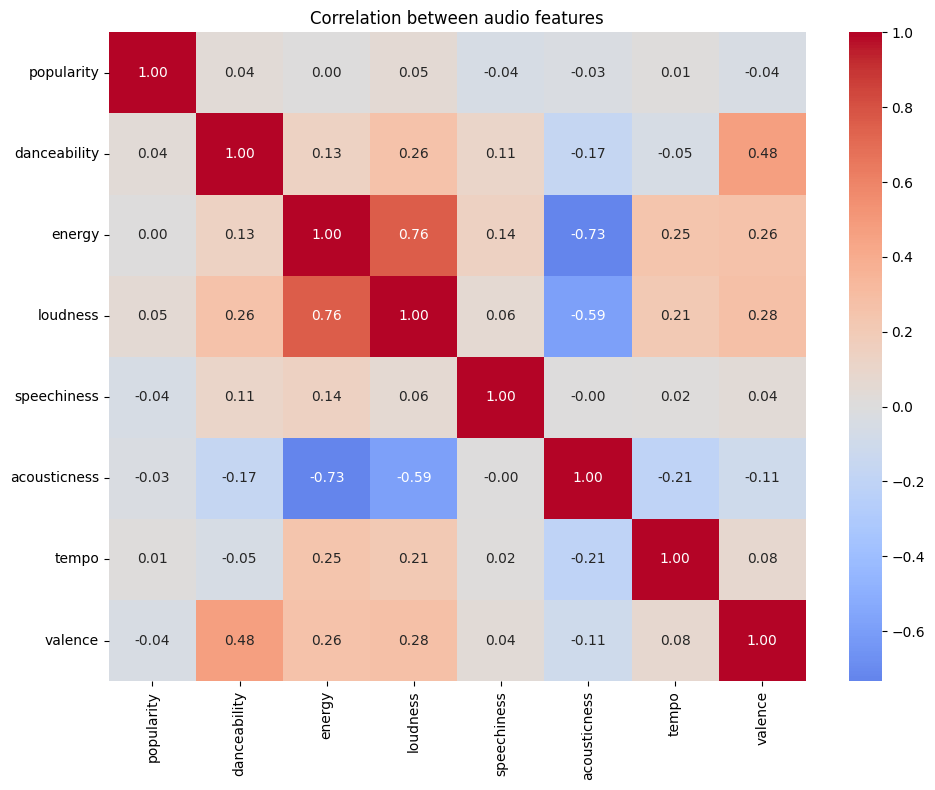

In [16]:
cols = ["popularity", "danceability", "energy", "loudness", 
        "speechiness", "acousticness", "tempo", "valence"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", 
            cmap="coolwarm", center=0)
plt.title("Correlation between audio features")
plt.tight_layout()
plt.savefig("../output/charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Cella 10 — Profilo medio Pop vs Hip-Hop vs Rock:

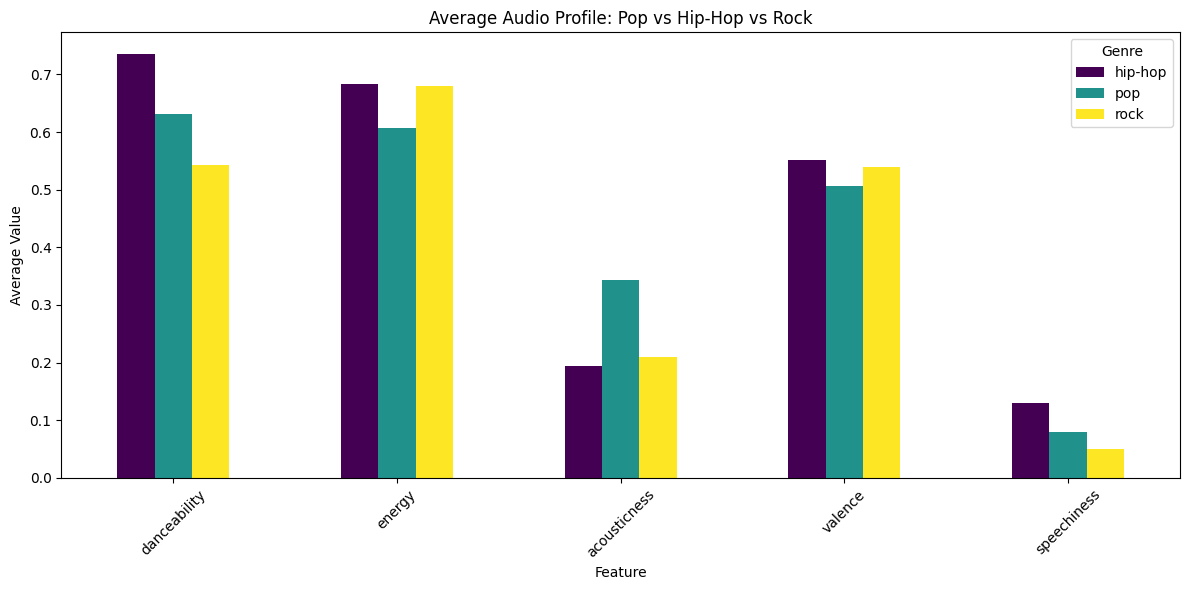

In [17]:
genres = ["pop", "hip-hop", "rock"]
cols = ["danceability", "energy", "acousticness", "valence", "speechiness"]

profile = df[df["track_genre"].isin(genres)]\
    .groupby("track_genre")[cols].mean()

profile.T.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Average Audio Profile: Pop vs Hip-Hop vs Rock")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Genre")
plt.tight_layout()
plt.savefig("../output/charts/genre_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusions

- The dataset contains **113,999** tracks across 114 different genres
- Most songs have popularity **close to zero** - only a few are truly dominant
- **The Beatles** have the highest number of tracks in the dataset (~250)
- The genres with the **highest average duration** are techno and house - DJ genres
- **Energy e loudness** are strongly correlated (more energy = more volume)
- **Pop, hip-hop e rock** have distinct and recognizable audio profiles